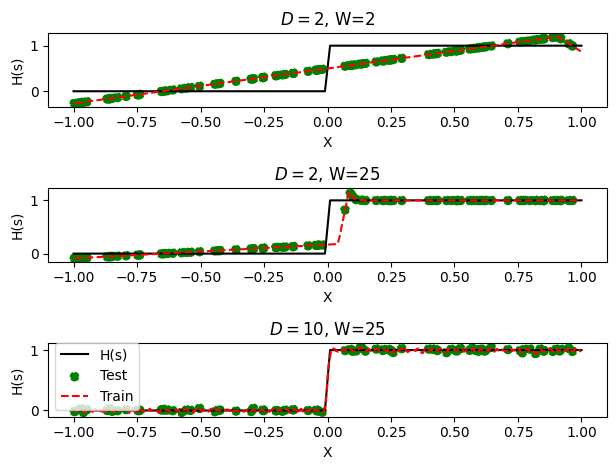

In [ ]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from matplotlib import cm
from nonlinear_approximator import (
    activations,
    inference,
    model,
    params,
    training, 
)
from scipy.stats import qmc
from sklearn.linear_model import Ridge, RidgeCV, Lasso
%matplotlib inline

# Parameters 
config1 = params.RegressionParams(
    width=2,
    depth=2,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

config2 = params.RegressionParams(
    width=25,
    depth=2,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

config3 = params.RegressionParams(
    width=25,
    depth=10,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

def gen_neurons(dimension, number):
    # neurons = np.random.normal(loc=0, scale=1, size=(config.input_dimension, config.width))
    # neurons = np.random.uniform(low=-1, high=1, size=(config.input_dimension, config.width))
    # neurons = neurons / np.linalg.norm(neurons, axis=0)
    # neurons = np.asarray(neurons)    
    sampler = qmc.LatinHypercube(d=dimension)
    sample = sampler.random(n=number) 
    
    return sample
def rmse(x, y):
    return np.mean(np.abs(x.squeeze()-y.squeeze()))
    return np.sqrt(np.mean(np.square(x - y)))
    
def tent(x, mu=1.99):
    nonlinear_params = {"alpha": 900, "beta": -0.06045, "r": 3.99, "mu": 1.99}

    # return np.exp(-900 * np.square(x)) + -0.06045
    return mu * np.minimum(x, 1 - x)

def step(x):
    out = np.zeros_like(x)
    out[x > 0] = 1
    out[x == 0] = .5
    return out


def compute_activations(neurons, input_x, config):
    num_samples, dim_input = input_x.shape
    # neurons have dim_input x config.width shape
    activations = np.zeros((num_samples, config.depth, config.width))
    for idx_sample in range(num_samples):
        for idx_layer in range(config.depth):
            if idx_layer == 0:
                # dots = neurons.T @ input_x[idx_sample, :]
                # activations[idx_sample, idx_layer, :] = np.where(dots > 0, dots, 0)
                sample =  np.expand_dims(input_x[idx_sample, :], axis=-1)
                activations[idx_sample, idx_layer, :] = .5*(sample+1).T @ neurons#1 - np.linalg.norm(neurons - sample,axis=0)/(2 * np.sqrt(dim_input))

            else:
                activations[idx_sample, idx_layer, :] = tent(
                    activations[idx_sample, idx_layer - 1, :]
                )
    return activations
        
def flatten_activations(acts: NDArray[np.floating]) -> NDArray[np.floating]:
    num_samples, depth, width = acts.shape
    flattened = np.zeros((num_samples, depth * width), dtype=np.float64)
    for idx_sample in range(num_samples):
        flattened[idx_sample, :] = np.copy(np.ravel(acts[idx_sample, :, :]))
    return flattened

def accum(input_x, output_y, neurons, config):
    batch_size = 256
    n_samples = input_x.shape[0]
    batch_xs = np.array_split(input_x, n_samples // batch_size, axis=0)
    batch_ys = np.array_split(output_y, n_samples // batch_size, axis=0)
    DW = config.depth * config.width
    AtA = np.zeros((DW, DW))
    Atb = np.zeros((DW,))
    for batch_x, batch_y in zip(batch_xs, batch_ys):
        A_batch = flatten_activations(compute_activations(
            neurons, input_x=batch_x, config=config
        ))
        AtA += A_batch @ A_batch
        Atb += A_batch.T @ output_y
    return AtA, Atb

xs = np.expand_dims(np.linspace(-1, 1, 100),axis=-1)
xs_train =np.random.uniform(-1, 1, (1000,1) ) 
xs_test = np.random.uniform(-1, 1, (100,1) )
plt.figure('h')
plt.clf()

for idx, config in enumerate([ config1, config2, config3]):
    plt.subplot(3,1,idx+1)
    plt.plot(xs, step(xs), label='H(s)', c='black')


    neurons = gen_neurons(config.input_dimension, config.width).T

    # zero mean input
    acts_train = compute_activations(
        neurons=neurons, input_x=xs_train, config=config
    )
    acts_test = compute_activations(
        neurons=neurons, input_x=xs_test, config=config
    )
    acts_train_flat = flatten_activations(acts_train)
    acts_test_flat = flatten_activations(acts_test)

    AtA, Atb = accum(input_x=xs_train, output_y=step(xs_train), )
    clf = Ridge(alpha=1e-3, tol=1e-16)
    # clf = Lasso(alpha=1e-5)
    clf.fit(acts_train_flat, step(xs_train))
    truth_test = step(xs_test)
    preds = clf.predict(acts_test_flat)
    preds_fit = clf.predict(acts_train_flat)
    # if idx == 2:
    #     # inset Axes....
    #     x1, x2, y1, y2 = -1, -0.7, -.003, 0.004  # subregion of the original image
    #     ax = plt.gca()
    #     axins = ax.inset_axes(
    #         [0.15, 0.45, 0.2, 0.5],
    #         xlim=(x1, x2), ylim=(y1, y2))
    #     axins.plot(xs, preds, ls='dotted', c='g')
    #     axins.plot(xs, step(xs), label='H(x)', c='black')
        

    #     ax.indicate_inset_zoom(axins, edgecolor="black", )
    #     axins.ticklabel_format(style='scientific', axis='both', scilimits=(0, 0))

    sortidx_train = np.argsort(xs_train,axis=0)
    sortidx_test = np.argsort(xs_test, axis=0)
    
    truth_test = truth_test[sortidx_test].squeeze()
    
    # err = rmse(truth_test[sortidx_test], preds[sortidx_test]) 
    plt.scatter(xs_test[sortidx_test].squeeze(), preds[sortidx_test].squeeze(), ls='--', c='g', label='Test')
    plt.plot(xs_train[sortidx_train].squeeze(), preds_fit[sortidx_train].squeeze(), ls='--', c='r', label='Train')
    plt.xlabel("X")
    plt.ylabel("H(s)")
    plt.title(f"$D={config.depth}$, W={config.width}")

plt.legend()
plt.gcf().tight_layout()
plt.ion()
plt.show()